In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b")
result=llm.invoke("Hey!!")
result

d:\agenticai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hey there! 👋 How’s it going? Is there anything I can help you with today?', additional_kwargs={'reasoning_content': 'The user says "Hey!!". This is a casual greeting. We should respond politely, maybe ask how they are or what they need. The user didn\'t ask a question. So we can respond with a friendly greeting and ask how we can help.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 73, 'total_tokens': 153, 'completion_time': 0.089430154, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.006226589, 'prompt_tokens_details': None, 'queue_time': 0.051547236, 'total_time': 0.095656743}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fa981-3aca-7883-8661-7417a51832b0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 80, 'total_tokens':

In [2]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[add,multiply,divide]
tools

[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>]

In [3]:
binded=llm.bind_tools(tools)
binded

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000020707F3BD10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000207080EAE50>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and

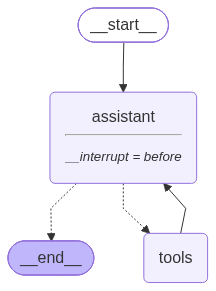

In [4]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, START, END, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage
from IPython.display import Image, display

sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")

def assistant(state:MessagesState):
    return {"messages":[binded.invoke([sys_msg] + state["messages"])]}

graph=StateGraph(MessagesState)

graph.add_node("assistant",assistant)
graph.add_node("tools",ToolNode(tools))


graph.add_edge(START,"assistant")
graph.add_conditional_edges(
    "assistant",
    tools_condition,

)
graph.add_edge("tools","assistant")

memory=MemorySaver()

build=graph.compile(interrupt_before=["assistant"],checkpointer=memory)

display(Image(build.get_graph().draw_mermaid_png()))

In [5]:
thread={"configurable":{"thread_id":"123"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

In [6]:
for event in build.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [7]:
state=build.get_state(thread)
state.next

('assistant',)

In [8]:
build.get_state_history(thread)

<generator object Pregel.get_state_history at 0x00000207084F7CC0>

In [9]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='0b456a25-74c6-41b7-b1c4-5f7082683983')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18a9f5-ceca-693d-8000-2f4b4847093b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-28T16:14:08.864287+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f18a9f5-cec5-6b34-bfff-975fa4e9826e'}}, tasks=(PregelTask(id='d76fbce5-7e72-12eb-cd8a-61ec135e8cb7', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [10]:
for event in build.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_b24ee8bd-451d-4e31-9ef6-405592791447)
 Call ID: fc_b24ee8bd-451d-4e31-9ef6-405592791447
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [11]:
state=build.get_state(thread)
state.next

('assistant',)

In [12]:
for event in build.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

6


In [13]:
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

thread={"configurable":{"thread_id":"1"}}
for event in build.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [14]:
state=build.get_state(thread)
state.next

('assistant',)

In [15]:
build.update_state(thread,{"messages":[HumanMessage(content="No,please multiply 15 and 6")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f18a9f5-d82c-685e-8001-1086e631525f'}}

In [16]:
new_state=build.get_state(thread).values

for m in new_state['messages']:
    m.pretty_print()


================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

No,please multiply 15 and 6


In [17]:
for event in build.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No,please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_453f4351-2f9f-47e2-8db2-1b71c4dfd9f5)
 Call ID: fc_453f4351-2f9f-47e2-8db2-1b71c4dfd9f5
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: multiply

90


In [18]:
for event in build.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

90
================================== Ai Message ==================================

The product of 15 and 6 is **90**.


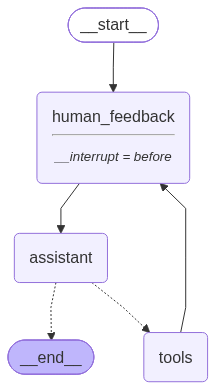

In [19]:
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


def human_feedback(state:MessagesState):
    pass

def assistant(state:MessagesState):
    return {"messages": [binded.invoke([sys_msg] + state["messages"])]}

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)


builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools","human_feedback")

memory=MemorySaver()
graph=builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))


In [22]:
initial_input = {"messages": "Multiply 2 and 3"}

thread = {"configurable": {"thread_id": "5"}}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()


user_input=input("Tell me how you want to update the state:")
graph.update_state(thread,{"messages":user_input},as_node="human_feedback")

for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

Multiply 6 by 7
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_709f06eb-d3af-4096-9b29-c074d39554a6)
 Call ID: fc_709f06eb-d3af-4096-9b29-c074d39554a6
  Args:
    a: 6
    b: 7
================================= Tool Message =================================
Name: multiply

42


In [23]:
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

42
================================== Ai Message ==================================

42
